In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ViTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class HybridViTEncoder(nn.Module):
    """
    Hybrid ViT encoder (20x20 tokens):

      x [B,1,80,80]
        -> CNN stem (stride=2 twice) => [B, Cstem, 20, 20]
        -> 1x1 proj to ViT hidden    => [B, D, 20, 20]
        -> flatten to tokens         => [B, 400, D]
        -> prepend CLS (optional)    => [B, 401, D]
        -> add interpolated pos      => [B, 401, D]
        -> ViT encoder               => [B, 401, D]
        -> readout (CLS/mean)        => [B, D]
        -> layernorm + heads         => mu/logvar [B, latent_dim]
    """

    def __init__(
        self,
        latent_dim: int = 128,
        vit_name: str = "google/vit-base-patch16-224-in21k",
        stem_out_channels: int = 256,
        train_last_k_blocks: int = 4,
        use_cls_token: bool = True,
    ):
        super().__init__()
        self.use_cls_token = use_cls_token

        # --- CNN stem: downsample 80->40->20 ---
        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1),   # 80 -> 40
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 40 -> 20
            nn.ReLU(inplace=True),
            nn.Conv2d(128, stem_out_channels, kernel_size=3, stride=1, padding=1),  # keep 20
            nn.ReLU(inplace=True),
        )

        self.vit = ViTModel.from_pretrained(vit_name)
        hidden = self.vit.config.hidden_size  # e.g. 768

        # project CNN feature map channels to ViT hidden dim
        self.proj = nn.Conv2d(stem_out_channels, hidden, kernel_size=1)

        # latent heads
        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)

        # --- Freeze / unfreeze policy ---
        for p in self.vit.parameters():
            p.requires_grad = False

        blocks = self.vit.encoder.layer
        if train_last_k_blocks > 0:
            for blk in blocks[-train_last_k_blocks:]:
                for p in blk.parameters():
                    p.requires_grad = True

        for p in self.vit.layernorm.parameters():
            p.requires_grad = True

        # position embeddings and cls token
        self.vit.embeddings.position_embeddings.requires_grad = True
        if self.use_cls_token:
            self.vit.embeddings.cls_token.requires_grad = True

        # cache (avoid re-interpolating pos embed every forward)
        self.register_buffer("_pos_cache", torch.empty(0), persistent=False)
        self._pos_cache_hw = None  # (Hf, Wf)

    @staticmethod
    def _interpolate_pos_embed(vit: ViTModel, Hf: int, Wf: int, use_cls: bool) -> torch.Tensor:
        """
        Interpolate pretrained pos_embed (14x14) to (Hf x Wf).

        Returns:
          - [1, 1+Hf*Wf, D] if use_cls
          - [1, Hf*Wf, D]   if not use_cls
        """
        pos = vit.embeddings.position_embeddings  # [1, 1+196, D]
        cls_pos = pos[:, :1, :]                   # [1, 1, D]
        patch_pos = pos[:, 1:, :]                 # [1, 196, D]

        D = patch_pos.shape[-1]
        N0 = patch_pos.shape[1]
        H0 = W0 = int(N0 ** 0.5)                  # 14

        patch_pos_2d = patch_pos.reshape(1, H0, W0, D).permute(0, 3, 1, 2)  # [1,D,14,14]
        patch_pos_2d = F.interpolate(
            patch_pos_2d, size=(Hf, Wf), mode="bicubic", align_corners=False
        )  # [1,D,Hf,Wf]
        patch_pos_new = patch_pos_2d.permute(0, 2, 3, 1).reshape(1, Hf * Wf, D)  # [1,Hf*Wf,D]

        return torch.cat([cls_pos, patch_pos_new], dim=1) if use_cls else patch_pos_new

    def _get_pos_embed(self, Hf: int, Wf: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        """
        Cached pos embedding for current (Hf,Wf). Recomputes if shape changes.
        """
        if self._pos_cache_hw != (Hf, Wf) or self._pos_cache.numel() == 0:
            pos = self._interpolate_pos_embed(self.vit, Hf, Wf, self.use_cls_token)
            self._pos_cache = pos.to(device=device, dtype=dtype)
            self._pos_cache_hw = (Hf, Wf)
        else:
            # ensure dtype/device match (AMP may change dtype)
            if self._pos_cache.device != device or self._pos_cache.dtype != dtype:
                self._pos_cache = self._pos_cache.to(device=device, dtype=dtype)
        return self._pos_cache

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # x: [B,1,80,80]
        B = x.size(0)

        # [B,Cstem,20,20]
        feat = self.stem(x)

        # [B,D,20,20]
        feat = self.proj(feat)

        # tokens: [B,Hf*Wf,D]
        _, D, Hf, Wf = feat.shape
        patch_tokens = feat.flatten(2).transpose(1, 2)  # [B,400,D] for 20x20

        if self.use_cls_token:
            cls_tokens = self.vit.embeddings.cls_token.expand(B, -1, -1)  # [B,1,D]
            tokens = torch.cat([cls_tokens, patch_tokens], dim=1)         # [B,401,D]
        else:
            tokens = patch_tokens                                         # [B,400,D]

        # add (cached) interpolated position embeddings
        pos_new = self._get_pos_embed(Hf, Wf, device=tokens.device, dtype=tokens.dtype)  # [1,*,D]
        tokens = tokens + pos_new

        # dropout like ViT
        tokens = self.vit.embeddings.dropout(tokens)

        # transformer encoder
        h = self.vit.encoder(tokens)[0]  # [B,*,D]

        # readout
        rep = h[:, 0] if self.use_cls_token else h.mean(dim=1)  # [B,D]
        rep = self.vit.layernorm(rep)

        mu = self.fc_mu(rep)
        logvar = self.fc_logvar(rep)
        return mu, logvar


class Encoder(nn.Module):
    def __init__(self, latent_dim: int = 128):
        super().__init__()
        self.enc = HybridViTEncoder(latent_dim=latent_dim)

    def forward(self, x: torch.Tensor):
        return self.enc(x)


def reparameterize(mu: torch.Tensor, logvar: torch.Tensor, noise_scale: float) -> torch.Tensor:
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + noise_scale * eps * std


class Decoder(nn.Module):
    def __init__(self, latent_dim: int = 128):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 10 * 10)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        h = self.fc(z).view(z.size(0), 128, 10, 10)
        return self.dec(h)  # logits [B,1,80,80]


class Predictor(nn.Module):
    def __init__(self, latent_dim: int = 128, output_dim: int = 160):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, output_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class VAEWithPredictor(nn.Module):
    def __init__(self, latent_dim: int = 128, pred_output_dim: int = 160):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.predictor = Predictor(latent_dim, pred_output_dim)

    def forward(self, x: torch.Tensor, noise_scale: float = 1.0):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar, noise_scale)
        x_recon = self.decoder(z)
        y_pred = self.predictor(mu)  # keep your original choice
        return x_recon, y_pred, mu, logvar, z


if __name__ == "__main__":
    latent_dim = 128
    pred_dim = 160
    model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=pred_dim).to(device)

    v = torch.randn(2, 1, 80, 80).to(device)
    x_recon, y_pred, mu, logvar, z = model(v, noise_scale=1.0)

    print("Input:", v.shape)
    print("Reconstruction:", x_recon.shape)
    print("Prediction:", y_pred.shape)
    print("Latent mean:", mu.shape)
    print("Latent var:", logvar.shape)
    print("Latent sample:", z.shape)



Input: torch.Size([2, 1, 80, 80])
Reconstruction: torch.Size([2, 1, 80, 80])
Prediction: torch.Size([2, 160])
Latent mean: torch.Size([2, 128])
Latent var: torch.Size([2, 128])
Latent sample: torch.Size([2, 128])


In [2]:
from dataloader import build_loaders
if __name__ == "__main__":
    for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
        train_loader, val_loader, train_ds, val_ds = build_loaders(
            data_root=".",
            n=3,
            batch_size=16,
            test_ratio=0.1,
            seed=42,
            augment_factor=4,
            subset_fraction=frac,
        )

        print(f"\nfrac = {frac}")
        print(f"train raw subset size = {train_ds.num_raw}")
        print(f"train augmented size  = {len(train_ds)}")
        print(f"val raw size          = {val_ds.num_raw}")
        print(f"val size              = {len(val_ds)}")
        print(f"train batches         = {len(train_loader)}")
        print(f"val batches           = {len(val_loader)}")

[INFO] Clean scaling setup
  Raw total files:      1000
  Raw train pool files: 900
  Raw val files:        100
  subset_fraction:      0.2
  Raw train subset:     180
  Train effective size: 720 (= 180 x 4)
  Val effective size:   100 (= 100 x 1)

frac = 0.2
train raw subset size = 180
train augmented size  = 720
val raw size          = 100
val size              = 100
train batches         = 45
val batches           = 7
[INFO] Clean scaling setup
  Raw total files:      1000
  Raw train pool files: 900
  Raw val files:        100
  subset_fraction:      0.4
  Raw train subset:     360
  Train effective size: 1440 (= 360 x 4)
  Val effective size:   100 (= 100 x 1)

frac = 0.4
train raw subset size = 360
train augmented size  = 1440
val raw size          = 100
val size              = 100
train batches         = 90
val batches           = 7
[INFO] Clean scaling setup
  Raw total files:      1000
  Raw train pool files: 900
  Raw val files:        100
  subset_fraction:      0.6
  Raw tr

In [3]:
# ------------------------------
# Overfitting a single batch test
# Hybrid ViT-VAE-Predictor
# ------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataloader import build_loaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------
# 1) Load a tiny batch
# ----------------------
train_loader, val_loader, train_ds, val_ds = build_loaders(
    data_root=".",
    n=2,
    batch_size=2,
    test_ratio=0.1,
    seed=42,
    num_workers=0,
    pin_memory=True,
    augment_factor=4,     
    subset_fraction=0.2,   
)

print("train raw size:", train_ds.num_raw)
print("train total size:", len(train_ds))
print("val raw size:", val_ds.num_raw)
print("val total size:", len(val_ds))
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

print("Input batch:", xb.shape, "range:", float(xb.min()), float(xb.max()))
print("Output batch:", yb.shape)

# ----------------------
# 2) Init model
# ----------------------
latent_dim = 128
output_dim = yb.shape[1]
model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=output_dim).to(device)
model.train()

# ----------------------
# 3) Optimizer with param groups
# ----------------------
vit_params, nonvit_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "encoder.enc.vit." in name:
        vit_params.append(p)
    else:
        nonvit_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": nonvit_params, "lr": 1e-3, "weight_decay": 1e-4},
        {"params": vit_params,    "lr": 5e-5, "weight_decay": 1e-4},
    ]
)

# Loss weights
beta = 1e-2
lambda_pred = 1.0
mse = nn.MSELoss()

def grad_mean(g):
    if g is None:
        return None
    return g.detach().abs().mean().item()

# ----------------------
# 4) Training loop
# ----------------------
for step in range(2000):
    x_recon, y_pred, mu, logvar, z = model(xb, noise_scale=1.0)

    # Recon: logits vs binary targets
    recon_loss = F.binary_cross_entropy_with_logits(x_recon, xb)

    # KL: scale-fixed
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl.mean(dim=1).mean()

    pred_loss = mse(y_pred, yb)

    loss = recon_loss + beta * kl + lambda_pred * pred_loss

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        enc = model.encoder.enc

        conv_stem_w = enc.stem[0].weight
        w_first = enc.vit.encoder.layer[0].output.dense.weight
        w_last  = enc.vit.encoder.layer[-1].output.dense.weight
        pos     = enc.vit.embeddings.position_embeddings
        ln_w    = next(iter(enc.vit.layernorm.parameters()))

        print(
            f"Step {step:04d} | "
            f"Recon={recon_loss.item():.6f} | "
            f"KL={kl.item():.6f} | "
            f"Pred={pred_loss.item():.6f} | "
            f"Total={loss.item():.6f}\n"
            f"  ConvStem: req={conv_stem_w.requires_grad} grad={grad_mean(conv_stem_w.grad)}\n"
            f"  ViTBlock0: req={w_first.requires_grad} grad={grad_mean(w_first.grad)}\n"
            f"  ViTBlockLast: req={w_last.requires_grad} grad={grad_mean(w_last.grad)}\n"
            f"  PosEmbed: req={pos.requires_grad} grad={grad_mean(pos.grad)}\n"
            f"  LayerNorm: req={ln_w.requires_grad} grad={grad_mean(ln_w.grad)}",
            flush=True
        )

print("Overfitting test finished.")

[INFO] Clean scaling setup
  Raw total files:      1000
  Raw train pool files: 900
  Raw val files:        100
  subset_fraction:      0.2
  Raw train subset:     180
  Train effective size: 720 (= 180 x 4)
  Val effective size:   100 (= 100 x 1)
train raw size: 180
train total size: 720
val raw size: 100
val total size: 100
train batches: 360
val batches: 50
Input batch: torch.Size([2, 1, 80, 80]) range: 0.0 1.0
Output batch: torch.Size([2, 80])
Step 0000 | Recon=0.693793 | KL=0.007301 | Pred=3566.621582 | Total=3567.315430
  ConvStem: req=True grad=0.005838385317474604
  ViTBlock0: req=False grad=None
  ViTBlockLast: req=True grad=5.4973435908323154e-05
  PosEmbed: req=True grad=0.0012612425489351153
  LayerNorm: req=True grad=0.024530582129955292
Step 0050 | Recon=0.308726 | KL=10.293932 | Pred=1857.465210 | Total=1857.876831
  ConvStem: req=True grad=0.6100268959999084
  ViTBlock0: req=False grad=None
  ViTBlockLast: req=True grad=0.0026560539845377207
  PosEmbed: req=True grad=0.

In [5]:
from dataloader import build_loaders

fractions = [0.1, 0.3, 0.6, 1.0]

val_sets = []

for f in fractions:
    train_loader, val_loader, train_ds, val_ds = build_loaders(
        data_root=".",
        n=3,
        batch_size=4,
        test_ratio=0.1,
        seed=42,
        augment_factor=4,
        subset_fraction=f,
    )

    files = val_ds.input_files
    val_sets.append(files)

    print(f"\nsubset_fraction = {f}")
    print("num val files:", len(files))
    print("first 5 files:", files[:5])


# check equality
print("\nChecking if validation sets are identical...\n")

base = set(val_sets[0])
for i in range(1, len(val_sets)):
    if set(val_sets[i]) != base:
        print(f"Mismatch between fraction {fractions[0]} and {fractions[i]}")
    else:
        print(f"OK: fraction {fractions[0]} == {fractions[i]}")


subset_fraction = 0.1
num val files: 100
first 5 files: ['.\\geometries\\dip_qr_500_20_0975.csv', '.\\geometries\\dip_qr_500_20_0612.csv', '.\\geometries\\dip_qr_500_20_0584.csv', '.\\geometries\\dip_qr_500_20_0949.csv', '.\\geometries\\dip_qr_500_20_0070.csv']

subset_fraction = 0.3
num val files: 100
first 5 files: ['.\\geometries\\dip_qr_500_20_0975.csv', '.\\geometries\\dip_qr_500_20_0612.csv', '.\\geometries\\dip_qr_500_20_0584.csv', '.\\geometries\\dip_qr_500_20_0949.csv', '.\\geometries\\dip_qr_500_20_0070.csv']

subset_fraction = 0.6
num val files: 100
first 5 files: ['.\\geometries\\dip_qr_500_20_0975.csv', '.\\geometries\\dip_qr_500_20_0612.csv', '.\\geometries\\dip_qr_500_20_0584.csv', '.\\geometries\\dip_qr_500_20_0949.csv', '.\\geometries\\dip_qr_500_20_0070.csv']

subset_fraction = 1.0
num val files: 100
first 5 files: ['.\\geometries\\dip_qr_500_20_0975.csv', '.\\geometries\\dip_qr_500_20_0612.csv', '.\\geometries\\dip_qr_500_20_0584.csv', '.\\geometries\\dip_qr_500_20_

In [2]:
# ------------------------------
# Overfitting a single batch test (FINAL)
# Hybrid ViT-VAE-Predictor:
# - CNN: 80->40 only
# - ViT: last 4 blocks + layernorm + pos_embed trainable
# - Recon: BCEWithLogits (decoder outputs logits)
# - KL: per-dim mean (scale-fixed)
# ------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataloader import build_loaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------
# 1) Load a tiny batch
# ----------------------
train_loader, test_loader, dataset = build_loaders(
    data_root=".",
    n=2,
    batch_size=2
)
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

print("Input batch:", xb.shape, "range:", float(xb.min()), float(xb.max()))
print("Output batch:", yb.shape)

# ----------------------
# 2) Init model
# ----------------------
latent_dim = 128
output_dim = yb.shape[1]
model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=output_dim).to(device)
model.train()

# ----------------------
# 3) Optimizer with param groups
# ----------------------
vit_params, nonvit_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "encoder.enc.vit." in name:
        vit_params.append(p)
    else:
        nonvit_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": nonvit_params, "lr": 1e-3, "weight_decay": 1e-4},
        {"params": vit_params,    "lr": 5e-5, "weight_decay": 1e-4},
    ]
)

# Loss weights
beta = 1e-2
lambda_pred = 1.0
mse = nn.MSELoss()

def grad_mean(g):
    if g is None:
        return None
    return g.detach().abs().mean().item()

# ----------------------
# 4) Training loop
# ----------------------
for step in range(2000):
    x_recon, y_pred, mu, logvar, z = model(xb, noise_scale=1.0)

    # Recon: logits vs binary targets
    recon_loss = F.binary_cross_entropy_with_logits(x_recon, xb)

    # KL: scale-fixed (mean over latent dim and batch)
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # [B,D]
    kl = kl.mean(dim=1).mean()

    pred_loss = mse(y_pred, yb)

    loss = recon_loss + beta * kl + lambda_pred * pred_loss

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        enc = model.encoder.enc  # HybridViTEncoder

        # grads
        conv_stem_w = enc.stem[0].weight
        w_first = enc.vit.encoder.layer[0].output.dense.weight
        w_last  = enc.vit.encoder.layer[-1].output.dense.weight
        pos     = enc.vit.embeddings.position_embeddings
        ln_w    = next(iter(enc.vit.layernorm.parameters()))

        print(
            f"Step {step:04d} | "
            f"Recon={recon_loss.item():.6f} | "
            f"KL={kl.item():.6f} | "
            f"Pred={pred_loss.item():.6f} | "
            f"Total={loss.item():.6f}\n"
            f"  ConvStem: req={conv_stem_w.requires_grad} grad={grad_mean(conv_stem_w.grad)}\n"
            f"  ViTBlock0: req={w_first.requires_grad} grad={grad_mean(w_first.grad)}\n"
            f"  ViTBlockLast: req={w_last.requires_grad} grad={grad_mean(w_last.grad)}\n"
            f"  PosEmbed: req={pos.requires_grad} grad={grad_mean(pos.grad)}\n"
            f"  LayerNorm: req={ln_w.requires_grad} grad={grad_mean(ln_w.grad)}"
        )

print("Overfitting test finished.")



c:\Users\15989\anaconda3\envs\pytorch_new\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Input batch: torch.Size([2, 1, 80, 80]) range: 0.0 1.0
Output batch: torch.Size([2, 80])
Step 0000 | Recon=0.689815 | KL=0.007610 | Pred=5098.583984 | Total=5099.273926
  ConvStem: req=True grad=0.005901620723307133
  ViTBlock0: req=False grad=None
  ViTBlockLast: req=True grad=7.400868344120681e-05
  PosEmbed: req=True grad=0.001373577630147338
  LayerNorm: req=True grad=0.034457214176654816
Step 0050 | Recon=0.213361 | KL=13.655383 | Pred=1299.077515 | Total=1299.427490
  ConvStem: req=True grad=1.4886709451675415
  ViTBlock0: req=False grad=None
  ViTBlockLast: req=True grad=0.0025958579499274492
  PosEmbed: req=True grad=0.07203143835067749
  LayerNorm: req=True grad=1.0698329210281372
Step 0100 | Recon=0.191767 | KL=11.451859 | Pred=1219.210083 | Total=1219.516357
  ConvStem: req=True grad=0.05880463123321533
  ViTBlock0: req=False grad=None
  ViTBlockLast: req=True grad=0.0003572761779651046
  PosEmbed: req=True grad=0.004293079487979412
  LayerNorm: req=True grad=0.1223857030272

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


2.5.1
True
NVIDIA GeForce RTX 4060 Laptop GPU


[INFO] cuda available: True
[INFO] device: cuda
[INFO] GPU name: NVIDIA GeForce RTX 4060 Laptop GPU

[INFO] Data loaded.
  Train batches: 225 | Val batches: 25
  Train samples: 3600 | Val samples: 400
[INFO] Param split: ViT=28,505,088 | nonViT=2,616,705
[INFO] Resumed from best_hybridvit_20x20_last4_posLN_rawdeg_128.pt at epoch 700
[INFO] best_val_loss_raw = 25.1512389755249
Epoch 700 | Stage2(joint) | Train: 0.034454 | recon=0.011569 | kl=1.361357 | pred=0.000927 | beta=0.01 | LR(nonViT)=2.06e-04 | LR(ViT)=1.10e-05 | time=64.8s
Epoch 701 | Stage2(joint) | Train: 0.016944 | recon=0.001096 | kl=1.305360 | pred=0.000279 | beta=0.01 | LR(nonViT)=2.04e-04 | LR(ViT)=1.10e-05 | time=63.5s
Epoch 702 | Stage2(joint) | Train: 0.015815 | recon=0.001079 | kl=1.268935 | pred=0.000205 | beta=0.01 | LR(nonViT)=2.03e-04 | LR(ViT)=1.09e-05 | time=64.1s
Epoch 703 | Stage2(joint) | Train: 0.015412 | recon=0.001085 | kl=1.256092 | pred=0.000177 | beta=0.01 | LR(nonViT)=2.02e-04 | LR(ViT)=1.09e-05 | time

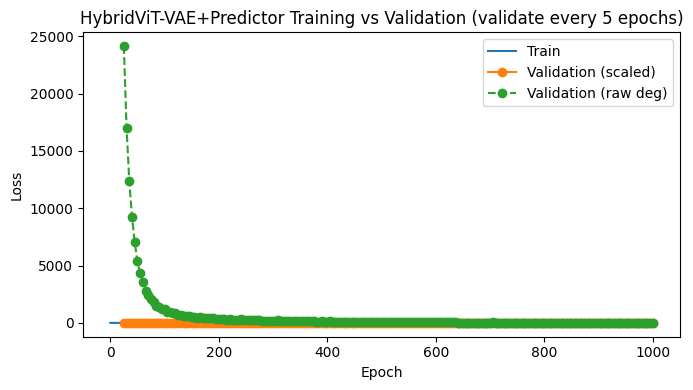

In [3]:
import os
import time
import warnings

import torch
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

from dataloader import build_loaders

# -----------------------------
# 0) Clean warnings (optional but recommended in notebooks)
# -----------------------------
warnings.filterwarnings("ignore", category=FutureWarning)

# -----------------------------
# 1) Device (HARD REQUIRE CUDA)
# -----------------------------
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is NOT available. You are currently running CPU-only.\n"
        "Fix your environment first (install CUDA-enabled PyTorch + GPU driver), "
        "otherwise this hybrid ViT training will be extremely slow."
    )

device = torch.device("cuda")
print("[INFO] cuda available:", torch.cuda.is_available())
print("[INFO] device:", device)
print("[INFO] GPU name:", torch.cuda.get_device_name(0))

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# -----------------------------
# 2) Data (Windows: num_workers MUST be 0)
# -----------------------------
train_loader, val_loader, dataset = build_loaders(
    data_root=".",
    n=3,
    batch_size=16,
    test_ratio=0.1,
    seed=42,
    pin_memory=True,
    num_workers=0,      # <-- REQUIRED on your setup
    augment_factor=4
)

print("\n[INFO] Data loaded.")
print(f"  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"  Train samples: {len(train_loader.dataset)} | Val samples: {len(val_loader.dataset)}")

# -----------------------------
# 3) Model
# -----------------------------
latent_dim = 128
pred_output_dim = 2**3 * 10 * 2  # 160

# assumes VAEWithPredictor exists in your env (now using 20x20-token encoder)
model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=pred_output_dim).to(device)

# -----------------------------
# 4) Optimizer / Scheduler + ViT param split sanity check (robust matcher)
# -----------------------------
vit_params, nonvit_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    # robust across wrapper nesting; catches encoder.enc.vit.*, vit.encoder.*, etc.
    if ".vit." in name:
        vit_params.append(p)
    else:
        nonvit_params.append(p)

vit_numel = sum(p.numel() for p in vit_params)
nonvit_numel = sum(p.numel() for p in nonvit_params)
print(f"[INFO] Param split: ViT={vit_numel:,} | nonViT={nonvit_numel:,}")
if vit_numel == 0:
    raise RuntimeError("vit_params is EMPTY. Check model.named_parameters() to fix the matcher.")

optimizer = optim.AdamW(
    [
        {"params": nonvit_params, "lr": 1e-3, "weight_decay": 1e-4},
        {"params": vit_params,    "lr": 5e-5, "weight_decay": 1e-4},
    ],
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000, eta_min=1e-6)

# -----------------------------
# 5) Checkpoint / Resume  (NEW run_tag for 20x20 to avoid collisions)
# -----------------------------
run_tag = "hybridvit_20x20_last4_posLN_rawdeg_128"
ckpt_best   = f"best_{run_tag}.pt"
ckpt_latest = f"latest_{run_tag}.pt"

resume = True  # do NOT resume from old 40x40 run; shapes differ

num_epochs = 1000
validate_every = 5
start_epoch = 0
best_val_loss_raw = float("inf")

train_losses = []
val_losses = []
val_losses_raw = []
val_epochs = []

scaler = torch.amp.GradScaler("cuda", enabled=True)

if resume and os.path.exists(ckpt_best):
    ckpt = torch.load(ckpt_best, map_location="cuda")
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    val_losses_raw = ckpt.get("val_losses_raw", [])
    val_epochs = ckpt.get("val_epochs", [])
    best_val_loss_raw = ckpt.get("best_val_loss_raw", best_val_loss_raw)
    start_epoch = ckpt.get("epoch", 0) + 1

    print(f"[INFO] Resumed from {ckpt_best} at epoch {start_epoch}")

print("[INFO] best_val_loss_raw =", best_val_loss_raw)

# -----------------------------
# 6) Losses
# -----------------------------
def kl_divergence(mu, logvar):
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # [B, D]
    return kl.mean(dim=1).mean()

def mag_ang_losses(y_pred_flat, y_true_flat):
    out = y_pred_flat.view(-1, 2**3, 10, 2)
    y   = y_true_flat.view(-1, 2**3, 10, 2)

    pred_mag     = F.softplus(out[..., 0])
    pred_ang_deg = out[..., 1]

    true_mag     = y[..., 0]
    true_ang_deg = y[..., 1]

    diff_deg = pred_ang_deg - true_ang_deg
    diff_rad = torch.deg2rad(diff_deg)
    delta_deg = torch.rad2deg(torch.atan2(torch.sin(diff_rad), torch.cos(diff_rad)))

    mse_mag = F.mse_loss(pred_mag, true_mag)
    mse_ang_scaled = F.mse_loss(delta_deg / 180.0, torch.zeros_like(delta_deg))
    mse_ang_raw = F.mse_loss(delta_deg, torch.zeros_like(delta_deg))

    pred_loss_scaled = mse_mag + mse_ang_scaled
    pred_loss_rawdeg = mse_mag + mse_ang_raw
    return pred_loss_scaled, pred_loss_rawdeg

# -----------------------------
# 7) Training setting
# -----------------------------
stage1_epochs = 20
beta_stage1 = 5e-3
beta_max = 1e-2
beta_warmup_epochs = 50
lambda_pred = 10.0

def beta_schedule(epoch):
    if epoch < stage1_epochs:
        return beta_stage1
    t = epoch - stage1_epochs
    frac = min(1.0, t / max(1, beta_warmup_epochs))
    return beta_stage1 + (beta_max - beta_stage1) * frac

def noise_schedule(epoch):
    if epoch < stage1_epochs:
        t = epoch / max(1, stage1_epochs - 1)
        return 0.1 + 0.9 * t
    return 1.0

max_grad_norm = 1.0

# -----------------------------
# 8) Training loop (fixed VAL noise + meters + finite checks)
# -----------------------------
for epoch in range(start_epoch, num_epochs):
    model.train()

    beta = beta_schedule(epoch)
    in_stage1 = (epoch < stage1_epochs)
    in_stage2 = (epoch >= stage1_epochs)
    noise_scale = noise_schedule(epoch)

    train_loss = 0.0
    recon_meter = 0.0
    kl_meter = 0.0
    pred_meter = 0.0

    t0 = time.time()

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=True):
            x_recon, y_pred, mu, logvar, z = model(x, noise_scale=noise_scale)

            recon_loss = F.binary_cross_entropy_with_logits(x_recon, x)
            kl = kl_divergence(mu, logvar)

            if in_stage2:
                pred_loss_scaled, _ = mag_ang_losses(y_pred, y)
                loss = recon_loss + beta * kl + lambda_pred * pred_loss_scaled
            else:
                loss = recon_loss + beta * kl

        if not torch.isfinite(kl):
            raise FloatingPointError(f"KL is not finite at epoch {epoch}. kl={kl.item()}")
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Loss is not finite at epoch {epoch}. loss={loss.item()}")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        train_loss += loss.item() * bs
        recon_meter += recon_loss.item() * bs
        kl_meter    += kl.item() * bs
        if in_stage2:
            pred_meter += pred_loss_scaled.item() * bs

    scheduler.step()

    N = len(train_loader.dataset)
    train_loss /= N
    recon_epoch = recon_meter / N
    kl_epoch    = kl_meter / N
    pred_epoch  = (pred_meter / N) if in_stage2 else 0.0
    train_losses.append(train_loss)

    epoch_sec = time.time() - t0
    stage_name = "Stage2(joint)" if in_stage2 else "Stage1(recon+KL)"
    print(
        f"Epoch {epoch:03d} | {stage_name} | "
        f"Train: {train_loss:.6f} | recon={recon_epoch:.6f} | kl={kl_epoch:.6f} | pred={pred_epoch:.6f} | "
        f"beta={beta:.4g} | "
        f"LR(nonViT)={optimizer.param_groups[0]['lr']:.2e} | "
        f"LR(ViT)={optimizer.param_groups[1]['lr']:.2e} | "
        f"time={epoch_sec:.1f}s",
        flush=True
    )

    # -------------------------
    # Validation (fixed noise_scale)
    # -------------------------
    if in_stage2 and ((epoch + 1) % validate_every == 0):
        model.eval()

        val_loss = 0.0
        val_loss_raw = 0.0

        val_recon = 0.0
        val_kl = 0.0
        val_pred_scaled = 0.0
        val_pred_raw = 0.0

        val_noise_scale = 1.0

        with torch.no_grad(), torch.amp.autocast("cuda", enabled=True):
            for x, y in val_loader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                x_recon, y_pred, mu, logvar, z = model(x, noise_scale=val_noise_scale)

                recon_loss = F.binary_cross_entropy_with_logits(x_recon, x)
                kl = kl_divergence(mu, logvar)
                pred_loss_scaled, pred_loss_rawdeg = mag_ang_losses(y_pred, y)

                l = recon_loss + beta * kl + lambda_pred * pred_loss_scaled
                l_raw = recon_loss + beta * kl + lambda_pred * pred_loss_rawdeg

                bs = x.size(0)
                val_loss += l.item() * bs
                val_loss_raw += l_raw.item() * bs

                val_recon += recon_loss.item() * bs
                val_kl += kl.item() * bs
                val_pred_scaled += pred_loss_scaled.item() * bs
                val_pred_raw += pred_loss_rawdeg.item() * bs

        M = len(val_loader.dataset)
        val_loss /= M
        val_loss_raw /= M
        val_recon /= M
        val_kl /= M
        val_pred_scaled /= M
        val_pred_raw /= M

        val_losses.append(val_loss)
        val_losses_raw.append(val_loss_raw)
        val_epochs.append(epoch + 1)

        print(
            f"  [VAL] total_scaled={val_loss:.6f} total_rawdeg={val_loss_raw:.6f} | "
            f"recon={val_recon:.6f} kl={val_kl:.6f} pred_scaled={val_pred_scaled:.6f} pred_rawdeg={val_pred_raw:.6f} | "
            f"best_rawdeg={best_val_loss_raw:.6f}",
            flush=True
        )

        if val_loss_raw < best_val_loss_raw:
            best_val_loss_raw = val_loss_raw
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "val_losses_raw": val_losses_raw,
                "val_epochs": val_epochs,
                "best_val_loss_raw": best_val_loss_raw,
                "stage1_epochs": stage1_epochs,
                "beta_max": beta_max,
                "lambda_pred": lambda_pred,
                "beta_warmup_epochs": beta_warmup_epochs,
                "run_tag": run_tag,
            }, ckpt_best)
            print(f"[INFO] Best model updated -> {ckpt_best}", flush=True)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_losses_raw": val_losses_raw,
        "val_epochs": val_epochs,
        "best_val_loss_raw": best_val_loss_raw,
        "stage1_epochs": stage1_epochs,
        "beta_max": beta_max,
        "lambda_pred": lambda_pred,
        "beta_warmup_epochs": beta_warmup_epochs,
        "run_tag": run_tag,
    }, ckpt_latest)

print("\nTraining complete.")
print(f"Best validation RAW loss: {best_val_loss_raw:.6f}")

# -----------------------------
# 9) Plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(range(len(train_losses)), train_losses, label='Train')
if len(val_epochs) > 0:
    plt.plot(val_epochs, val_losses, 'o-', label='Validation (scaled)')
    plt.plot(val_epochs, val_losses_raw, 'o--', label='Validation (raw deg)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title(f"HybridViT-VAE+Predictor Training vs Validation (validate every {validate_every} epochs)")
plt.tight_layout()
plt.show()


C:\Users\15989\AppData\Local\Temp\ipykernel_2524\189877841.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location="cpu")


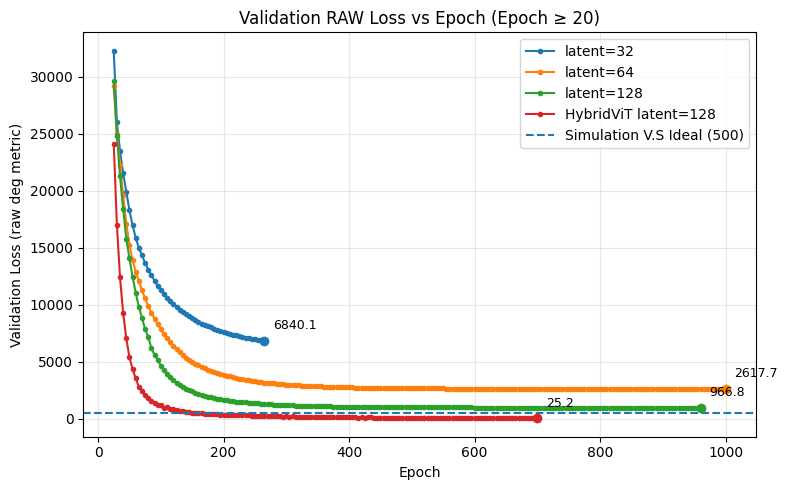

In [2]:
import torch
import matplotlib.pyplot as plt

ckpts = {
    "latent=32": "latest_vae_model_rawdeg.pt",
    "latent=64": "latest_vae_model_rawdeg_64.pt",
    "latent=128": "latest_vae_model_rawdeg_128.pt",

    # NEW hybrid ViT result
    "HybridViT latent=128": "latest_hybridvit_20x20_last4_posLN_rawdeg_128.pt",
}

VAL_KEY = "val_losses_raw"
AVG_SIM_ERROR = 500.0

START_EPOCH = 20   # <-- skip first 20 epochs

plt.figure(figsize=(8, 5))

for label, path in ckpts.items():
    try:
        ckpt = torch.load(path, map_location="cpu")
    except FileNotFoundError:
        print(f"[WARN] Missing ckpt: {path}")
        continue

    val_epochs = list(ckpt.get("val_epochs", []))
    val_losses = list(ckpt.get(VAL_KEY, []))

    if len(val_epochs) == 0 or len(val_epochs) != len(val_losses):
        print(f"[WARN] Skip {label}: length mismatch or empty")
        continue

    # -------- NEW: filter epochs >= 20 --------
    filtered = [(e, l) for e, l in zip(val_epochs, val_losses) if e >= START_EPOCH]

    if len(filtered) == 0:
        print(f"[WARN] Skip {label}: no epochs >= {START_EPOCH}")
        continue

    val_epochs_f, val_losses_f = zip(*filtered)

    # curve
    plt.plot(
        val_epochs_f,
        val_losses_f,
        marker="o",
        linewidth=1.5,
        markersize=3,
        label=label
    )

    # last point annotation
    x_last, y_last = val_epochs_f[-1], val_losses_f[-1]
    plt.scatter([x_last], [y_last], zorder=3)

    plt.annotate(
        f"{y_last:.1f}",
        xy=(x_last, y_last),
        xytext=(6, 6),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=9,
    )

# reference line
plt.axhline(
    y=AVG_SIM_ERROR,
    linestyle="--",
    linewidth=1.5,
    label="Simulation V.S Ideal (500)"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss (raw deg metric)")
plt.title("Validation RAW Loss vs Epoch (Epoch ≥ 20)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "val_rawdeg_compare_latent_dims.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [7]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import gridspec

from dataloader import DiplexDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# 0) Settings
# -------------------------
data_root = "."
n = 3
num_intervals = 2**n
s_labels = ["S11", "S12", "S13", "S14", "S22", "S23", "S24", "S33", "S34", "S44"]

model_path = "best_hybridvit_20x20_last4_posLN_rawdeg_128.pt"
latent_dim = 128
pred_output_dim = num_intervals * 10 * 2

out_dir = "viz_top_samples_with_input_128(ViT)"
os.makedirs(out_dir, exist_ok=True)

# -------------------------
# Your top-5 results
# -------------------------
TOP_VARIANCE = [
    {"sample_idx": 895, "label": "S23", "score": 0.165255},
    {"sample_idx": 946, "label": "S13", "score": 0.138433},
    {"sample_idx": 619, "label": "S34", "score": 0.135634},
    {"sample_idx": 369, "label": "S24", "score": 0.134992},
    {"sample_idx": 734, "label": "S11", "score": 0.133497},
]
TOP_P2P = [
    {"sample_idx": 73,  "label": "S14", "p2p": 0.993707},
    {"sample_idx": 78,  "label": "S23", "p2p": 0.98614},
    {"sample_idx": 3,   "label": "S13", "p2p": 0.958378},
    {"sample_idx": 877, "label": "S13", "p2p": 0.954927},
    {"sample_idx": 946, "label": "S13", "p2p": 0.933405},
]

# -------------------------
# 1) Helpers
# -------------------------
def load_clean_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=",", skiprows=1)
    df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]
    df.iloc[:, 0] = df.iloc[:, 0].astype(float)
    return df.reset_index(drop=True)

def compute_sample_idxs(freqs: np.ndarray, num_intervals: int):
    edges = np.linspace(freqs.min(), freqs.max(), num_intervals + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    idxs = np.abs(freqs[:, None] - centers[None, :]).argmin(axis=0)
    return idxs, centers

def wrap_angle_deg_torch(angle_deg: torch.Tensor) -> torch.Tensor:
    """Wrap degrees to [-180, 180] using smooth trig map."""
    ang_rad = torch.deg2rad(angle_deg)
    return torch.rad2deg(torch.atan2(torch.sin(ang_rad), torch.cos(ang_rad)))

def unwrap_angle_deg_np(angle_deg: np.ndarray) -> np.ndarray:
    """Unwrap degrees to a continuous curve (numpy)."""
    return np.rad2deg(np.unwrap(np.deg2rad(angle_deg)))

def wrap_angle_deg_np(angle_deg: np.ndarray) -> np.ndarray:
    """Wrap degrees to [-180, 180] (numpy)."""
    return (angle_deg + 180) % 360 - 180

# -------------------------
# 2) Load dataset & model
# -------------------------
dataset = DiplexDataset(
    data_root=data_root,
    n=n,
    transform=None,
    augment_factor=1
)

model = VAEWithPredictor(
    latent_dim=latent_dim,
    pred_output_dim=pred_output_dim
).to(device)

ckpt = torch.load(model_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# -------------------------
# 3) Core visualization (colors match your ORIGINAL script)
# -------------------------
def visualize_sample(sample_idx: int, metric_name: str, focus_label: str, score: float):
    print(f"[VIZ] sample #{sample_idx} | {metric_name} | focus={focus_label}")

    # ---- Load sample
    x, y_true = dataset[sample_idx]
    x_batch = x.unsqueeze(0).to(device)

    with torch.no_grad():
        x_recon, y_pred, mu, logvar, z = model(x_batch, noise_scale=1.0)
        y_pred = y_pred.detach().cpu().squeeze()

    # ---- Load CSV
    csv_path = dataset.output_files[sample_idx]
    df = load_clean_csv(csv_path)

    freqs = df.iloc[:, 0].to_numpy()
    idxs, _ = compute_sample_idxs(freqs, num_intervals)
    freqs_sampled = freqs[idxs]

    y_true = y_true.view(num_intervals, 10, 2)
    y_pred = y_pred.view(num_intervals, 10, 2)

    # model outputs
    y_pred_mag_pos = F.softplus(y_pred[:, :, 0])  # (num_intervals, 10)
    y_pred_ang_deg = y_pred[:, :, 1]             # (num_intervals, 10)

    all_mag_vals = []
    for lbl in s_labels:
        col = f"MAG[{lbl}]"
        if col in df.columns:
            all_mag_vals.append(df[col].to_numpy())
    all_mag_vals = np.concatenate(all_mag_vals) if len(all_mag_vals) else np.array([0.0, 1.0])
    mag_min = float(np.min(all_mag_vals))
    mag_max = float(np.max(all_mag_vals))

    # -------------------------
    # Figure layout
    #   row 0: input
    #   rows 1..10: S11..S44
    # -------------------------
    fig = plt.figure(figsize=(14, 20))
    gs = gridspec.GridSpec(
        11, 2,
        height_ratios=[1.3] + [1]*10,
        hspace=0.45,
        wspace=0.35
    )

    fig.suptitle(
        f"Sample #{sample_idx} | {metric_name} | focus={focus_label} | score={score:.4g}",
        fontsize=16,
        y=0.99
    )

    # ---- Input geometry
    ax_img = fig.add_subplot(gs[0, :])
    x_np = x.squeeze().cpu().numpy()
    if x_np.ndim == 3:
        x_np = x_np[0]
    ax_img.imshow(x_np, cmap="gray", interpolation="nearest")
    ax_img.set_title("Input Geometry", fontsize=12, pad=4)
    ax_img.axis("off")

    # -------------------------
    # Plot S-parameters
    # -------------------------
    for i, label in enumerate(s_labels):
        mag_col = f"MAG[{label}]"
        ang_col = f"ANG[{label}]"

        if mag_col not in df.columns or ang_col not in df.columns:
            continue

        true_mag_sampled = df.iloc[idxs][mag_col].to_numpy()
        true_ang_sampled = df.iloc[idxs][ang_col].to_numpy()

        # ===== MAG  =====
        ax_mag = fig.add_subplot(gs[i+1, 0])
        ax_mag.plot(df.iloc[:, 0], df[mag_col], lw=1.2, color="C0")
        ax_mag.scatter(freqs_sampled, true_mag_sampled, s=18, color="C0", zorder=5)
        ax_mag.plot(
            freqs_sampled,
            y_pred_mag_pos[:, i].numpy(),
            "--o",
            lw=1.4,
            markersize=3.5,
            color="orange",
            zorder=6
        )

        mse_mag = float(np.mean((y_pred_mag_pos[:, i].numpy() - true_mag_sampled) ** 2))
        ax_mag.set_title(f"{label} |MAG| (MSE={mse_mag:.3g})", fontsize=9, pad=2)
        ax_mag.set_ylim(mag_min - 0.05, mag_max + 0.05)
        ax_mag.grid(alpha=0.25)

        # ===== ANG (unwrap target+pred → wrap to [-180,180]) =====
        ax_ang = fig.add_subplot(gs[i+1, 1])

        true_ang_unwrap = unwrap_angle_deg_np(true_ang_sampled)
        true_ang_plot = wrap_angle_deg_np(true_ang_unwrap)

        pred_ang_np = y_pred_ang_deg[:, i].numpy()
        pred_ang_unwrap = unwrap_angle_deg_np(pred_ang_np)
        pred_ang_plot = wrap_angle_deg_np(pred_ang_unwrap)

        ax_ang.plot(df.iloc[:, 0], df[ang_col], lw=1.2, color="C2")
        ax_ang.scatter(freqs_sampled, true_ang_plot, s=18, color="C2", zorder=5)
        ax_ang.plot(
            freqs_sampled,
            pred_ang_plot,
            "--o",
            lw=1.4,
            markersize=3.5,
            color="red",
            zorder=6
        )

        # MSE using minimal angular difference
        diff_wrapped = wrap_angle_deg_np(pred_ang_plot - true_ang_plot)
        mse_ang = float(np.mean(diff_wrapped ** 2))

        ax_ang.set_title(f"{label} ∠ (MSE={mse_ang:.3g})", fontsize=9, pad=2)
        ax_ang.set_ylim(-180, 180)
        ax_ang.grid(alpha=0.25)

    # -------------------------
    # Save
    # -------------------------
    out_path = os.path.join(out_dir, f"{metric_name}_sample{sample_idx}_focus{focus_label}.png")
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"[INFO] saved → {out_path}")

# -------------------------
# 4) Run batch
# -------------------------
for r in TOP_VARIANCE:
    visualize_sample(
        r["sample_idx"],
        metric_name="VAR",
        focus_label=r["label"],
        score=r["score"]
    )

for r in TOP_P2P:
    visualize_sample(
        r["sample_idx"],
        metric_name="P2P",
        focus_label=r["label"],
        score=r["p2p"]
    )

print("\n[DONE] All visualizations generated.")


C:\Users\15989\AppData\Local\Temp\ipykernel_15980\363614015.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


[VIZ] sample #895 | VAR | focus=S23


C:\Users\15989\AppData\Local\Temp\ipykernel_15980\363614015.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


[INFO] saved → viz_top_samples_with_input_128(ViT)\VAR_sample895_focusS23.png
[VIZ] sample #946 | VAR | focus=S13


C:\Users\15989\AppData\Local\Temp\ipykernel_15980\363614015.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


...

[INFO] saved → viz_top_samples_with_input_128(ViT)\P2P_sample3_focusS13.png
[VIZ] sample #877 | P2P | focus=S13


C:\Users\15989\AppData\Local\Temp\ipykernel_15980\363614015.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


[INFO] saved → viz_top_samples_with_input_128(ViT)\P2P_sample877_focusS13.png
[VIZ] sample #946 | P2P | focus=S13


C:\Users\15989\AppData\Local\Temp\ipykernel_15980\363614015.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


[INFO] saved → viz_top_samples_with_input_128(ViT)\P2P_sample946_focusS13.png

[DONE] All visualizations generated.


In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# directories
# -------------------------
dir_vit = "viz_top_samples_with_input_128(ViT)"
dir_cnn = "viz_top_samples_with_input_128"

out_dir = "viz_compare_ViT_vs_CNN"
os.makedirs(out_dir, exist_ok=True)

# -------------------------
# collect filenames
# -------------------------
files_vit = set(os.listdir(dir_vit))
files_cnn = set(os.listdir(dir_cnn))

common_files = sorted(files_vit.intersection(files_cnn))

print(f"[INFO] Found {len(common_files)} matching images")

# -------------------------
# combine images
# -------------------------
for fname in common_files:

    path_vit = os.path.join(dir_vit, fname)
    path_cnn = os.path.join(dir_cnn, fname)

    try:
        img_vit = Image.open(path_vit)
        img_cnn = Image.open(path_cnn)
    except Exception as e:
        print(f"[WARN] skip {fname}: {e}")
        continue

    # make same height
    h = max(img_vit.height, img_cnn.height)

    def pad_to_height(img, target_h):
        if img.height == target_h:
            return img
        new_img = Image.new("RGB", (img.width, target_h), (255,255,255))
        new_img.paste(img, (0, 0))
        return new_img

    img_vit = pad_to_height(img_vit, h)
    img_cnn = pad_to_height(img_cnn, h)

    # combine horizontally
    combined = Image.new(
        "RGB",
        (img_vit.width + img_cnn.width, h),
        (255,255,255)
    )

    combined.paste(img_vit, (0, 0))
    combined.paste(img_cnn, (img_vit.width, 0))

    # save
    out_path = os.path.join(out_dir, fname)
    combined.save(out_path)

    print(f"[OK] saved → {out_path}")

print("\n[DONE]")


[INFO] Found 10 matching images
[OK] saved → viz_compare_ViT_vs_CNN\P2P_sample3_focusS13.png
[OK] saved → viz_compare_ViT_vs_CNN\P2P_sample73_focusS14.png
[OK] saved → viz_compare_ViT_vs_CNN\P2P_sample78_focusS23.png
[OK] saved → viz_compare_ViT_vs_CNN\P2P_sample877_focusS13.png
[OK] saved → viz_compare_ViT_vs_CNN\P2P_sample946_focusS13.png
[OK] saved → viz_compare_ViT_vs_CNN\VAR_sample369_focusS24.png
[OK] saved → viz_compare_ViT_vs_CNN\VAR_sample619_focusS34.png
[OK] saved → viz_compare_ViT_vs_CNN\VAR_sample734_focusS11.png
[OK] saved → viz_compare_ViT_vs_CNN\VAR_sample895_focusS23.png
[OK] saved → viz_compare_ViT_vs_CNN\VAR_sample946_focusS13.png

[DONE]


C:\Users\15989\AppData\Local\Temp\ipykernel_15980\4196825307.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


[INFO] Collected mu embeddings: (800, 128)
[PCA] KNN consistency (K=15): mean=0.0679, std=0.0848
[PCA] Trustworthiness(K=15): 0.6439
[PCA] Continuity(K=15):      0.7292
[PCA] Explained variance ratio (sum): 0.0890


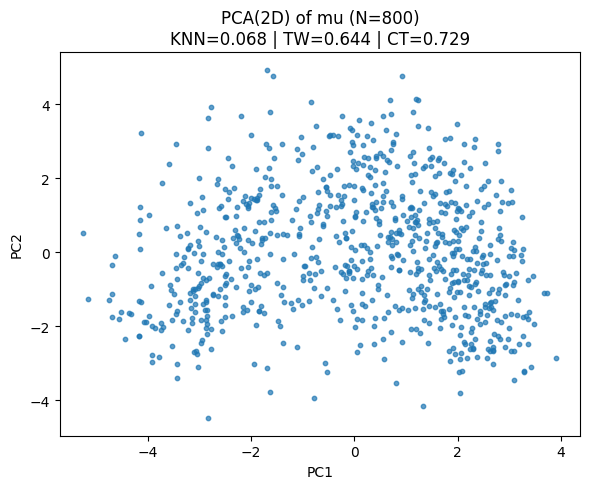

[t-SNE run 1/5] seed=100 | KNN mean=0.2265, std=0.1346 | TW=0.7617 | CT=0.7818
[t-SNE run 2/5] seed=101 | KNN mean=0.2227, std=0.1321 | TW=0.7513 | CT=0.7898
[t-SNE run 3/5] seed=102 | KNN mean=0.2290, std=0.1341 | TW=0.7569 | CT=0.7816
[t-SNE run 4/5] seed=103 | KNN mean=0.2229, std=0.1304 | TW=0.7545 | CT=0.7820
[t-SNE run 5/5] seed=104 | KNN mean=0.2279, std=0.1318 | TW=0.7538 | CT=0.7833
[t-SNE] Avg KNN mean over runs: 0.2258 ± 0.0026
[t-SNE best run #2] seed=102 | KNN mean=0.2290, std=0.1341 | TW=0.7569 | CT=0.7816


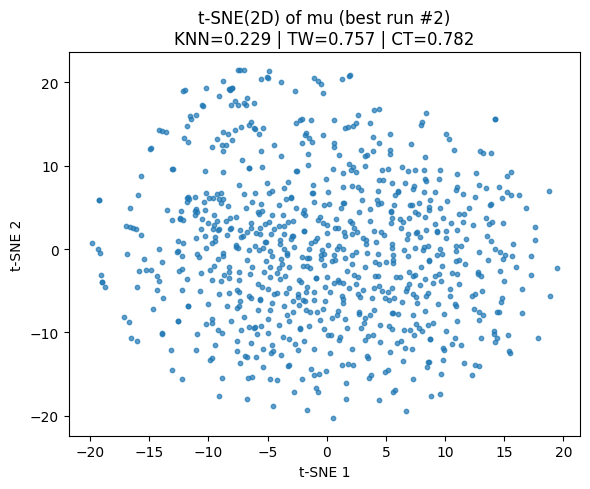

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from dataloader import DiplexDataset  

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.neighbors import NearestNeighbors


# -----------------------------
# Config
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "latest_hybridvit_20x20_last4_posLN_rawdeg_128.pt"
data_root = "."
n = 3
latent_dim = 128
pred_output_dim = (2**n) * 10 * 2

num_samples = 800
batch_size = 64

K = 15

pca_dim = 2
tsne_dim = 2

tsne_repeats = 5
tsne_perplexity = 30
tsne_learning_rate = "auto"
tsne_init = "pca"
tsne_n_iter = 1000


# -----------------------------
# Metrics
# -----------------------------
def knn_sets(X, K=15, metric="euclidean"):
    nn = NearestNeighbors(n_neighbors=K + 1, metric=metric).fit(X)
    neigh = nn.kneighbors(X, return_distance=False)[:, 1:]
    return neigh


def knn_consistency(high_X, low_Y, K=15, metric_high="euclidean", metric_low="euclidean"):
    nh = knn_sets(high_X, K=K, metric=metric_high)
    nl = knn_sets(low_Y, K=K, metric=metric_low)

    overlaps = np.empty(high_X.shape[0], dtype=np.float32)
    for i in range(high_X.shape[0]):
        overlaps[i] = len(set(nh[i]).intersection(set(nl[i]))) / K

    return overlaps.mean(), overlaps.std(), overlaps


def continuity(X_high, X_low, n_neighbors=15, metric="euclidean"):
    X_high = np.asarray(X_high)
    X_low = np.asarray(X_low)
    N = X_high.shape[0]
    k = int(n_neighbors)

    nn_low = NearestNeighbors(n_neighbors=N, metric=metric).fit(X_low)
    order_low = nn_low.kneighbors(X_low, return_distance=False)

    rank_low = np.empty((N, N), dtype=np.int32)
    for i in range(N):
        rank_low[i, order_low[i]] = np.arange(N, dtype=np.int32)

    nn_high = NearestNeighbors(n_neighbors=k + 1, metric=metric).fit(X_high)
    neigh_high = nn_high.kneighbors(X_high, return_distance=False)[:, 1:]

    penalty = 0.0
    for i in range(N):
        for j in neigh_high[i]:
            r_ij_low = rank_low[i, j]
            if r_ij_low > k:
                penalty += (r_ij_low - k)

    denom = float(N * k * (2 * N - 3 * k - 1))
    return float(1.0 - (2.0 / denom) * penalty)


# -----------------------------
# Data + Model
# -----------------------------
dataset = DiplexDataset(data_root=data_root, n=n, transform=None, augment_factor=1)

model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=pred_output_dim).to(device)
ckpt = torch.load(model_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()


def collect_mu(dataset, num_samples=None, batch_size=64):
    Nfull = len(dataset)
    N = Nfull if num_samples is None else min(int(num_samples), Nfull)
    idxs = np.random.permutation(Nfull)[:N].tolist()

    mus = []
    with torch.no_grad():
        for b0 in range(0, N, batch_size):
            batch_idx = idxs[b0 : b0 + batch_size]
            xs = [dataset[i][0] for i in batch_idx]
            x = torch.stack(xs, dim=0).to(device)

            _, _, mu, _, _ = model(x, noise_scale=1.0)
            mus.append(mu.detach().cpu().numpy())

    mu_all = np.concatenate(mus, axis=0)
    return mu_all, idxs


mu, used_idxs = collect_mu(dataset, num_samples=num_samples, batch_size=batch_size)
N, D = mu.shape
print(f"[INFO] Collected mu embeddings: {mu.shape}")


# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=pca_dim, random_state=0)
mu_centered = mu - mu.mean(axis=0, keepdims=True)
Y_pca = pca.fit_transform(mu_centered)

pca_mean, pca_std, _ = knn_consistency(mu, Y_pca, K=K)
tw_pca = trustworthiness(mu, Y_pca, n_neighbors=K, metric="euclidean")
ct_pca = continuity(mu, Y_pca, n_neighbors=K, metric="euclidean")

print(f"[PCA] KNN consistency (K={K}): mean={pca_mean:.4f}, std={pca_std:.4f}")
print(f"[PCA] Trustworthiness(K={K}): {tw_pca:.4f}")
print(f"[PCA] Continuity(K={K}):      {ct_pca:.4f}")
print(f"[PCA] Explained variance ratio (sum): {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(6, 5))
plt.scatter(Y_pca[:, 0], Y_pca[:, 1], s=10, alpha=0.7)
plt.title(f"PCA({pca_dim}D) of mu (N={N})\nKNN={pca_mean:.3f} | TW={tw_pca:.3f} | CT={ct_pca:.3f}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# -----------------------------
# t-SNE repeats
# -----------------------------
tsne_runs = []
tsne_embeds = []

for r in range(tsne_repeats):
    seed = 100 + r
    tsne = TSNE(
        n_components=tsne_dim,
        perplexity=tsne_perplexity,
        learning_rate=tsne_learning_rate,
        init=tsne_init,
        max_iter=tsne_n_iter,
        random_state=seed,
        verbose=0,
    )

    Y_tsne = tsne.fit_transform(mu)
    m, s, _ = knn_consistency(mu, Y_tsne, K=K)
    tw = trustworthiness(mu, Y_tsne, n_neighbors=K, metric="euclidean")
    ct = continuity(mu, Y_tsne, n_neighbors=K, metric="euclidean")

    tsne_runs.append((m, s, tw, ct, seed))
    tsne_embeds.append(Y_tsne)

    print(
        f"[t-SNE run {r+1}/{tsne_repeats}] seed={seed} | "
        f"KNN mean={m:.4f}, std={s:.4f} | TW={tw:.4f} | CT={ct:.4f}"
    )

tsne_means = np.array([m for (m, _, _, _, _) in tsne_runs], dtype=np.float32)
print(f"[t-SNE] Avg KNN mean over runs: {tsne_means.mean():.4f} ± {tsne_means.std():.4f}")

best_run = int(np.argmax(tsne_means))
best_m, best_s, best_tw, best_ct, best_seed = tsne_runs[best_run]
Y_best = tsne_embeds[best_run]

print(
    f"[t-SNE best run #{best_run}] seed={best_seed} | "
    f"KNN mean={best_m:.4f}, std={best_s:.4f} | TW={best_tw:.4f} | CT={best_ct:.4f}"
)

plt.figure(figsize=(6, 5))
plt.scatter(Y_best[:, 0], Y_best[:, 1], s=10, alpha=0.7)
plt.title(f"t-SNE({tsne_dim}D) of mu (best run #{best_run})\nKNN={best_m:.3f} | TW={best_tw:.3f} | CT={best_ct:.3f}")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


In [4]:
K_list = [5, 10, 15, 30, 50]

print("\n===== PCA sweep K =====")
for K0 in K_list:
    m, s, _ = knn_consistency(mu, Y_pca, K=K0)
    tw = trustworthiness(mu, Y_pca, n_neighbors=K0, metric="euclidean")
    ct = continuity(mu, Y_pca, n_neighbors=K0, metric="euclidean")
    print(f"[PCA] K={K0:2d} | KNN={m:.4f} | TW={tw:.4f} | CT={ct:.4f}")

print("\n===== t-SNE best run sweep K =====")
for K0 in K_list:
    m, s, _ = knn_consistency(mu, Y_best, K=K0)
    tw = trustworthiness(mu, Y_best, n_neighbors=K0, metric="euclidean")
    ct = continuity(mu, Y_best, n_neighbors=K0, metric="euclidean")
    print(f"[t-SNE best] K={K0:2d} | KNN={m:.4f} | TW={tw:.4f} | CT={ct:.4f}")



===== PCA sweep K =====
[PCA] K= 5 | KNN=0.0283 | TW=0.6406 | CT=0.7601
[PCA] K=10 | KNN=0.0519 | TW=0.6441 | CT=0.7437
[PCA] K=15 | KNN=0.0679 | TW=0.6439 | CT=0.7292
[PCA] K=30 | KNN=0.1108 | TW=0.6471 | CT=0.7074
[PCA] K=50 | KNN=0.1569 | TW=0.6521 | CT=0.6972

===== t-SNE best run sweep K =====
[t-SNE best] K= 5 | KNN=0.2845 | TW=0.8267 | CT=0.8307
[t-SNE best] K=10 | KNN=0.2460 | TW=0.7818 | CT=0.7995
[t-SNE best] K=15 | KNN=0.2290 | TW=0.7569 | CT=0.7816
[t-SNE best] K=30 | KNN=0.2226 | TW=0.7223 | CT=0.7558
[t-SNE best] K=50 | KNN=0.2390 | TW=0.7026 | CT=0.7419


c:\Users\15989\anaconda3\envs\pytorch_new\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[UMAP] KNN consistency (K=15): mean=0.0508, std=0.0568
[UMAP] Trustworthiness(K=15): 0.5681
[UMAP] Continuity(K=15):      0.6591


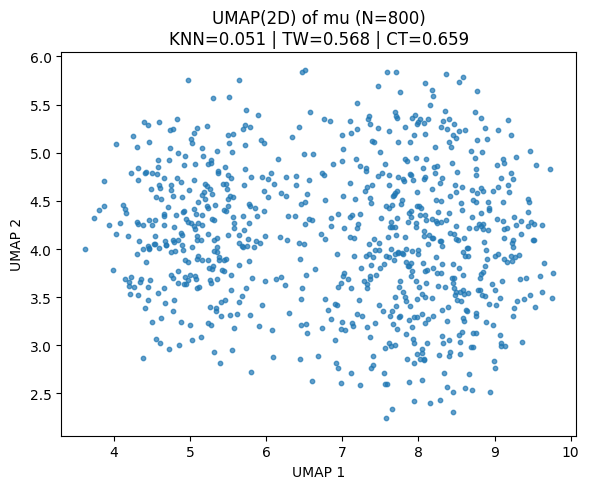

In [12]:
import umap  

# -----------------------------
# UMAP (2D)
# -----------------------------
umap_dim = 2
umap_n_neighbors = 15
umap_min_dist = 0.1
umap_metric = "euclidean"
umap_seed = 0

reducer = umap.UMAP(
    n_components=umap_dim,
    n_neighbors=umap_n_neighbors,
    min_dist=umap_min_dist,
    metric=umap_metric,
    random_state=umap_seed,
)

Y_umap = reducer.fit_transform(mu)

umap_mean, umap_std, _ = knn_consistency(mu, Y_umap, K=K)
tw_umap = trustworthiness(mu, Y_umap, n_neighbors=K, metric="euclidean")
ct_umap = continuity(mu, Y_umap, n_neighbors=K, metric="euclidean")

print(f"[UMAP] KNN consistency (K={K}): mean={umap_mean:.4f}, std={umap_std:.4f}")
print(f"[UMAP] Trustworthiness(K={K}): {tw_umap:.4f}")
print(f"[UMAP] Continuity(K={K}):      {ct_umap:.4f}")

plt.figure(figsize=(6, 5))
plt.scatter(Y_umap[:, 0], Y_umap[:, 1], s=10, alpha=0.7)
plt.title(
    f"UMAP({umap_dim}D) of mu (N={N})\n"
    f"KNN={umap_mean:.3f} | TW={tw_umap:.3f} | CT={ct_umap:.3f}"
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()


[Latent PCA energy]
  dims to reach 80% variance: 61
  dims to reach 90% variance: 83
  dims to reach 95% variance: 99
  dims to reach 99% variance: 119


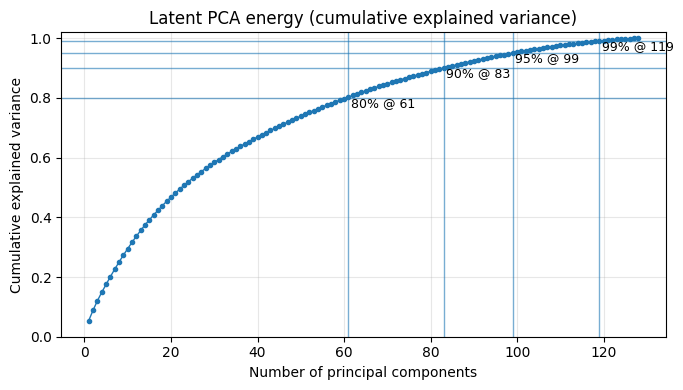

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def latent_pca_energy(mu, thresholds=(0.80, 0.90, 0.95, 0.99), center=True, random_state=0):
    mu = np.asarray(mu)
    X = mu - mu.mean(axis=0, keepdims=True) if center else mu

    pca = PCA(n_components=min(X.shape[1], X.shape[0]), random_state=random_state)
    pca.fit(X)

    evr = pca.explained_variance_ratio_            # (D,)
    cum = np.cumsum(evr)                          # (D,)

    dims_at = {}
    for t in thresholds:
        dims_at[t] = int(np.searchsorted(cum, t) + 1)

    print("[Latent PCA energy]")
    for t in thresholds:
        print(f"  dims to reach {t:.0%} variance: {dims_at[t]}")

    return evr, cum, dims_at


# ---- run ----
evr, cum, dims_at = latent_pca_energy(mu, thresholds=(0.80, 0.90, 0.95, 0.99))

# ---- plot ----
D = len(cum)
x = np.arange(1, D + 1)

plt.figure(figsize=(7, 4))
plt.plot(x, cum, marker="o", markersize=3, linewidth=1)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Latent PCA energy (cumulative explained variance)")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)

for t, d in dims_at.items():
    plt.axhline(t, linewidth=1, alpha=0.6)
    plt.axvline(d, linewidth=1, alpha=0.6)
    plt.text(d + 0.5, t - 0.03, f"{int(t*100)}% @ {d}", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import torch
import math

LOG2PI = math.log(2.0 * math.pi)

def log_normal_pdf(z, mu, logvar):
    # z, mu, logvar broadcastable
    return -0.5 * (LOG2PI + logvar + (z - mu) ** 2 / torch.exp(logvar))

@torch.no_grad()
def estimate_mi_per_dim(mu, logvar, L=1, M=2000, seed=0, device="cpu"):
    """
    Estimate MI per latent dim: I(X; Z_j) = E_x KL(q(z_j|x) || q(z_j)).
    mu, logvar: (N, D) torch tensors
    L: #samples per data point from q(z_j|x)
    M: mixture subset size for q(z_j) approximation (tradeoff speed/accuracy)
    Returns: mi: (D,) tensor (nats)
    """
    torch.manual_seed(seed)
    mu = mu.to(device).float()
    logvar = logvar.to(device).float()
    N, D = mu.shape

    # subset for aggregated posterior mixture
    if M >= N:
        idx = torch.arange(N, device=device)
    else:
        idx = torch.randperm(N, device=device)[:M]

    mu_mix = mu[idx]         # (M, D)
    lv_mix = logvar[idx]     # (M, D)

    # sample z ~ q(z|x): (N, D, L)
    eps = torch.randn(N, D, L, device=device)
    z = mu.unsqueeze(-1) + torch.exp(0.5 * logvar).unsqueeze(-1) * eps

    # log q(z|x): (N, D, L)
    log_q_z_given_x = log_normal_pdf(z, mu.unsqueeze(-1), logvar.unsqueeze(-1))

    # log q(z) where q is mixture over subset: (N, D, L)
    # compute component logpdfs: (N, M, D, L) -> might be heavy if N and M large
    # We'll loop over dims to keep memory bounded.
    mi = torch.zeros(D, device=device)

    for j in range(D):
        zj = z[:, j, :]                      # (N, L)
        log_qzx = log_q_z_given_x[:, j, :]   # (N, L)

        # mixture component logpdfs for this dim: (N, M, L)
        # log N(z; mu_mix[m,j], lv_mix[m,j])
        mu_m = mu_mix[:, j].view(1, M, 1)    # (1, M, 1)
        lv_m = lv_mix[:, j].view(1, M, 1)    # (1, M, 1)
        z_in = zj.view(N, 1, L)              # (N, 1, L)

        log_comp = log_normal_pdf(z_in, mu_m, lv_m)  # (N, M, L)

        # log q(z) = logmeanexp over mixture components
        log_qz = torch.logsumexp(log_comp, dim=1) - math.log(M)  # (N, L)

        # MI_j = E[log q(z|x) - log q(z)]
        mi[j] = (log_qzx - log_qz).mean()

    return mi  # nats

mi = estimate_mi_per_dim(mu_all, logvar_all, L=1, M=2000, device="cuda")


vals, idx = torch.sort(mi, descending=True)
print("Top-10 MI dims:")
for k in range(10):
    print(k+1, int(idx[k]), float(vals[k]))
print("Num near-zero dims:", int((mi < 1e-3).sum()))



===== UMAP: latent-dim correlations =====

[UMAP axis 1] Top-10 by |Pearson|:
   1. z[18]  pearson=-0.7675  spearman=-0.8075
   2. z[91]  pearson=-0.3882  spearman=-0.3588
   3. z[20]  pearson= 0.3235  spearman= 0.3196
   4. z[04]  pearson=-0.3223  spearman=-0.3142
   5. z[03]  pearson= 0.3186  spearman= 0.2742
   6. z[15]  pearson=-0.3039  spearman=-0.3106
   7. z[116]  pearson=-0.2952  spearman=-0.2852
   8. z[62]  pearson=-0.2876  spearman=-0.2543
   9. z[55]  pearson= 0.2296  spearman= 0.1960
  10. z[112]  pearson=-0.2095  spearman=-0.2070

[UMAP axis 2] Top-10 by |Pearson|:
   1. z[116]  pearson= 0.1416  spearman= 0.1332
   2. z[102]  pearson=-0.1300  spearman=-0.1213
   3. z[19]  pearson=-0.1191  spearman=-0.1058
   4. z[48]  pearson=-0.1174  spearman=-0.1046
   5. z[41]  pearson=-0.1136  spearman=-0.1131
   6. z[04]  pearson= 0.1109  spearman= 0.1117
   7. z[18]  pearson= 0.1087  spearman= 0.1319
   8. z[46]  pearson= 0.1081  spearman= 0.0990
   9. z[02]  pearson= 0.1033  spear

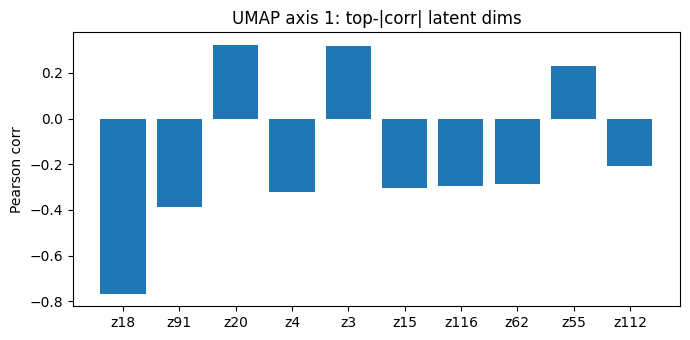

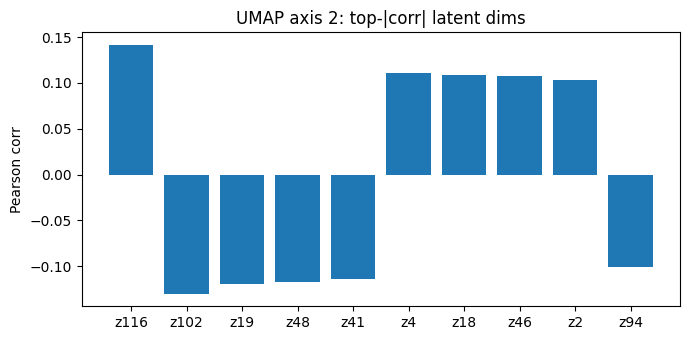

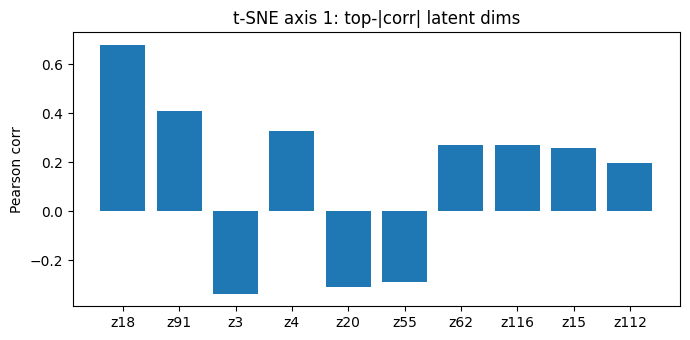

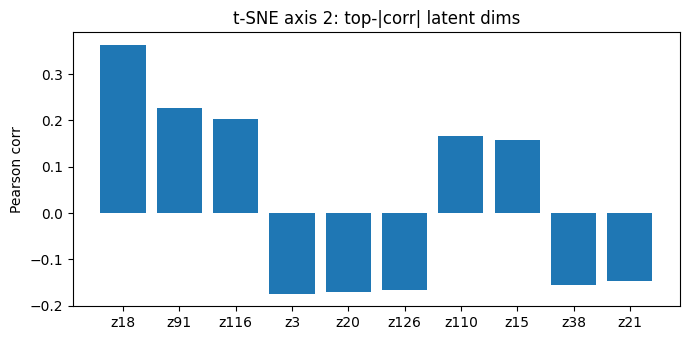

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def axis_latent_correlation(mu, Y, name="UMAP", topk=10):
    """
    Correlate each latent dimension with each embedding axis.
    Prints top-k latent dims by |corr| for each axis.
    """
    mu = np.asarray(mu)              # (N, D)
    Y  = np.asarray(Y)               # (N, 2) or (N, d)
    N, D = mu.shape
    d = Y.shape[1]

    def pearson_corr(a, b):
        a = a - a.mean()
        b = b - b.mean()
        denom = (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum()))
        return 0.0 if denom == 0 else float((a*b).sum() / denom)

    def spearman_corr(a, b):
        # rank-based correlation (no scipy needed)
        ra = np.argsort(np.argsort(a))
        rb = np.argsort(np.argsort(b))
        return pearson_corr(ra.astype(np.float64), rb.astype(np.float64))

    pearson = np.zeros((D, d), dtype=np.float64)
    spearman = np.zeros((D, d), dtype=np.float64)

    for j in range(D):
        zj = mu[:, j].astype(np.float64)
        for t in range(d):
            yt = Y[:, t].astype(np.float64)
            pearson[j, t] = pearson_corr(zj, yt)
            spearman[j, t] = spearman_corr(zj, yt)

    # Print top-k per axis
    print(f"\n===== {name}: latent-dim correlations =====")
    for t in range(d):
        idx = np.argsort(-np.abs(pearson[:, t]))[:topk]
        print(f"\n[{name} axis {t+1}] Top-{topk} by |Pearson|:")
        for rank, j in enumerate(idx, 1):
            print(f"  {rank:2d}. z[{j:02d}]  pearson={pearson[j,t]: .4f}  spearman={spearman[j,t]: .4f}")

    return pearson, spearman


def plot_topk_bar(corr_vec, title, topk=10):
    idx = np.argsort(-np.abs(corr_vec))[:topk]
    vals = corr_vec[idx]

    plt.figure(figsize=(7, 3.5))
    plt.bar(np.arange(topk), vals)
    plt.xticks(np.arange(topk), [f"z{j}" for j in idx], rotation=0)
    plt.ylabel("Pearson corr")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# --- Run for UMAP and t-SNE ---
# Requires you already have:
# mu: (N, 32)
# Y_umap: (N, 2)
# Y_best: (N, 2)  # your best t-SNE run

pear_umap, spear_umap = axis_latent_correlation(mu, Y_umap, name="UMAP", topk=10)
pear_tsne, spear_tsne = axis_latent_correlation(mu, Y_best, name="t-SNE", topk=10)

# --- Optional: visualize top correlations ---
plot_topk_bar(pear_umap[:, 0], "UMAP axis 1: top-|corr| latent dims", topk=10)
plot_topk_bar(pear_umap[:, 1], "UMAP axis 2: top-|corr| latent dims", topk=10)

plot_topk_bar(pear_tsne[:, 0], "t-SNE axis 1: top-|corr| latent dims", topk=10)
plot_topk_bar(pear_tsne[:, 1], "t-SNE axis 2: top-|corr| latent dims", topk=10)


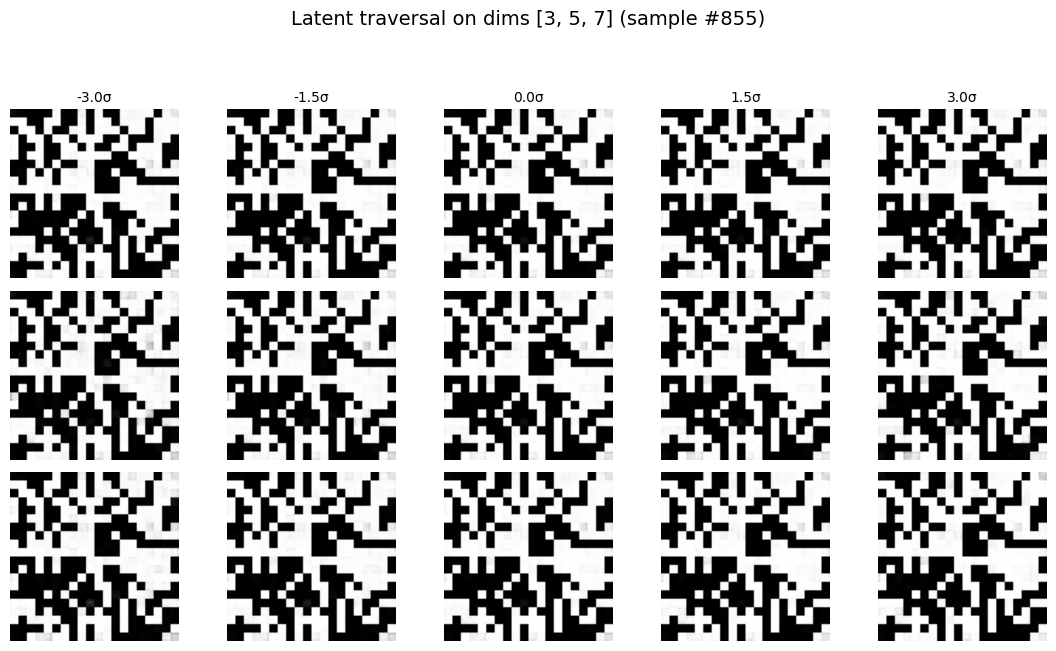

In [8]:
import torch
import matplotlib.pyplot as plt
from dataloader import DiplexDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- load model ----
latent_dim = 128
n = 3
pred_output_dim = 2**n * 10 * 2
model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=pred_output_dim).to(device)

ckpt = torch.load("latest_vae_model_rawdeg_128.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# ---- sample one x ----
dataset = DiplexDataset(data_root=".", n=n, transform=None, augment_factor=1)
idx = torch.randint(0, len(dataset), (1,)).item()
x, _ = dataset[idx]
x = x.unsqueeze(0).to(device)

# ---- get mu/logvar ----
with torch.no_grad():
    _, _, mu, logvar, _ = model(x, noise_scale=1.0)

mu = mu.squeeze(0)          # [D]
std = torch.exp(0.5 * logvar.squeeze(0))  # [D]

# ---- choose latent dims to traverse ----
ks = [3, 5, 7]                       # target latent dimensions
steps = torch.linspace(-3, 3, 5)     # 9 images per dimension

imgs_all = {}  # dict: k -> list of images

with torch.no_grad():
    for k in ks:
        imgs = []
        for s in steps:
            z = mu.clone()
            z[k] = mu[k] + s * std[k]   # traversal in units of std
            x_logits = model.decoder(z.unsqueeze(0))  # decode only
            x_prob = torch.sigmoid(x_logits).squeeze().cpu()
            imgs.append(x_prob)
        imgs_all[k] = imgs

# ---- plot ----
num_rows = len(ks)
num_cols = len(steps)

plt.figure(figsize=(2.2 * num_cols, 2.2 * num_rows))

for r, k in enumerate(ks):
    for c, im in enumerate(imgs_all[k]):
        ax = plt.subplot(num_rows, num_cols, r * num_cols + c + 1)
        ax.imshow(im, cmap="gray")
        ax.axis("off")

        if r == 0:
            ax.set_title(f"{steps[c].item():.1f}σ", fontsize=10)
        if c == 0:
            ax.set_ylabel(f"dim {k}", fontsize=11, rotation=0, labelpad=25)

plt.suptitle(f"Latent traversal on dims {ks} (sample #{idx})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



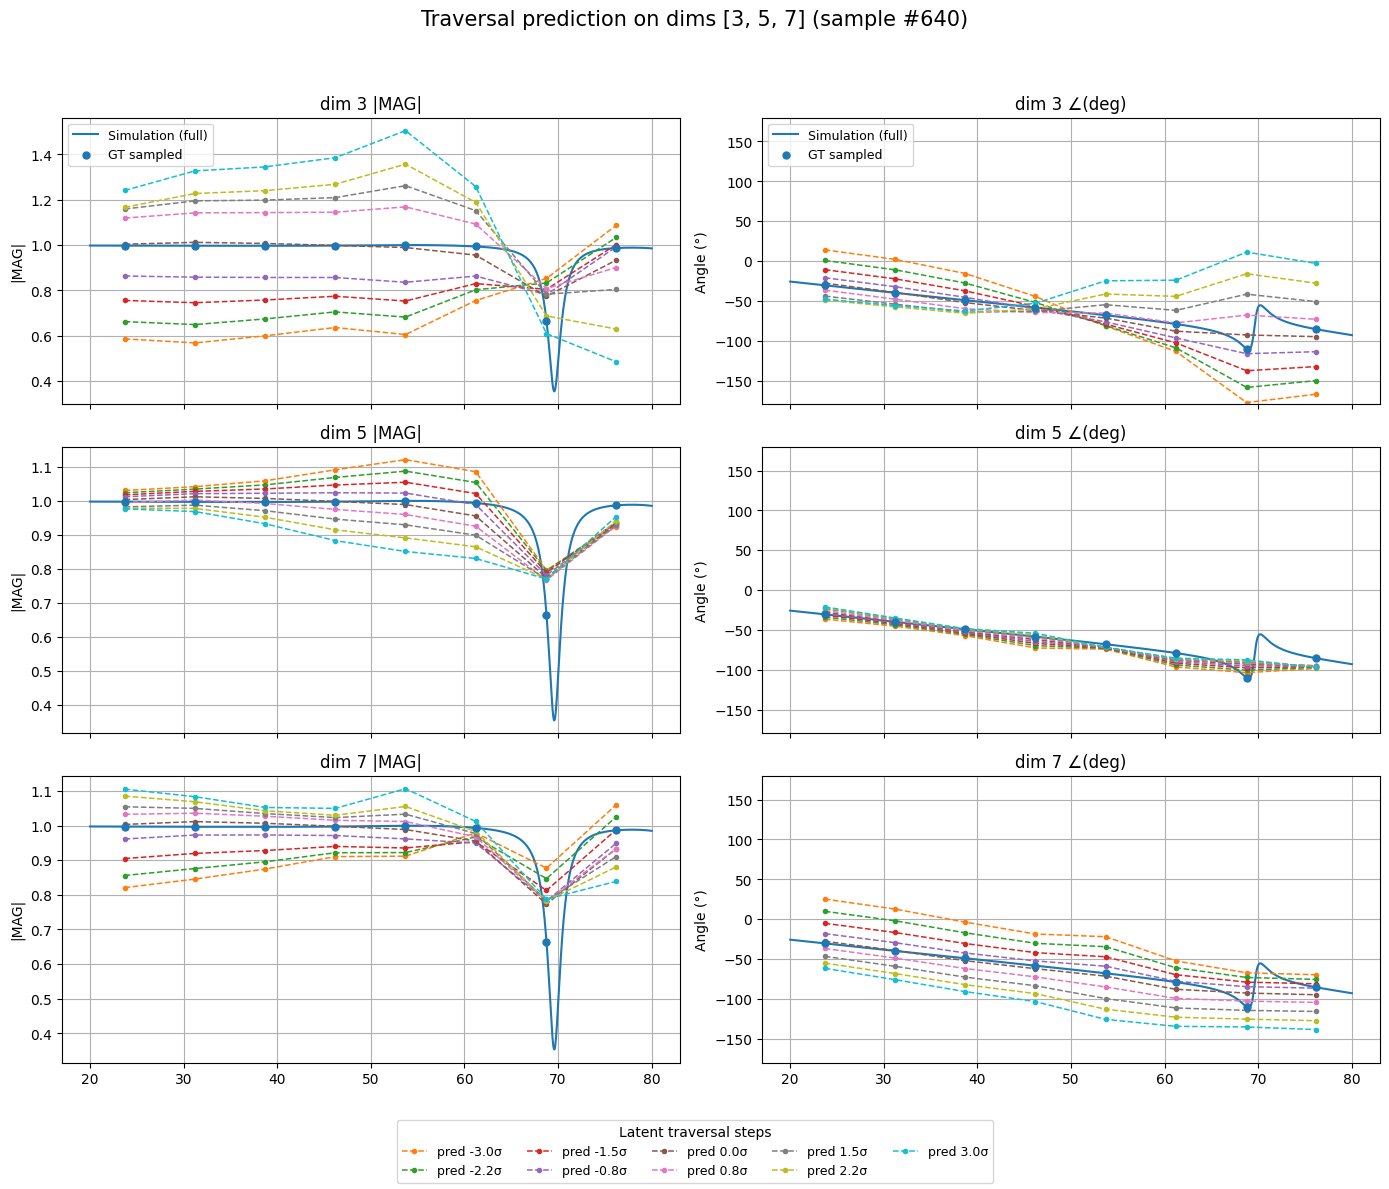

[INFO] Saved figure: traversal_pred_S11_2x3_dims[3, 5, 7]_sample640.png


In [10]:
# Traversal prediction visualization: 2 columns × 3 rows (dims 3/5/7)
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from dataloader import DiplexDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Settings ===
data_root = "."
model_path = "latest_vae_model_rawdeg_128.pt"
sample_idx = None
n = 3

label = "S11"
dims = [3, 5, 7]
steps = torch.linspace(-3, 3, 9)   # keep actual traversal steps

def wrap_deg(angle_deg):
    angle_rad = torch.deg2rad(angle_deg)
    return torch.rad2deg(torch.atan2(torch.sin(angle_rad), torch.cos(angle_rad)))

# === Load dataset & model ===
dataset = DiplexDataset(data_root=data_root, n=n, transform=None, augment_factor=1)

latent_dim = 128
pred_output_dim = 2**n * 10 * 2
model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=pred_output_dim).to(device)

ckpt = torch.load(model_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# === Pick sample ===
idx = sample_idx if sample_idx is not None else random.randint(0, len(dataset) - 1)
x, y_true = dataset[idx]
x = x.unsqueeze(0).to(device)

with torch.no_grad():
    _, _, mu, logvar, _ = model(x, noise_scale=1.0)
    std = torch.exp(0.5 * logvar)

mu = mu.squeeze(0)
std = std.squeeze(0)

# === Load CSV ===
csv_path = dataset.output_files[idx]
df = pd.read_csv(csv_path, sep=",", skiprows=1)
df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]
freqs = df.iloc[:, 0].astype(float).to_numpy()

num_intervals = 2**n
edges = np.linspace(freqs.min(), freqs.max(), num_intervals + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
idxs = np.abs(freqs[:, None] - centers[None, :]).argmin(axis=0)
freqs_sampled = freqs[idxs]

s_labels = ["S11", "S12", "S13", "S14", "S22", "S23", "S24", "S33", "S34", "S44"]
i = s_labels.index(label)

mag_col = f"MAG[{label}]"
ang_col = f"ANG[{label}]"

true_mag_sampled = df.loc[idxs, mag_col].to_numpy()
true_ang_sampled = df.loc[idxs, ang_col].to_numpy()

# === Traversal predictions ===
pred_mag_by_dim = {}
pred_ang_by_dim = {}

with torch.no_grad():
    for k in dims:
        mags, angs = [], []
        for s in steps:
            z = mu.clone()
            z[k] = mu[k] + s * std[k]

            y_pred = model.predictor(z.unsqueeze(0)).squeeze(0)
            y_pred = y_pred.view(num_intervals, 10, 2)

            mags.append(F.softplus(y_pred[:, i, 0]).cpu().numpy())
            angs.append(wrap_deg(y_pred[:, i, 1]).cpu().numpy())

        pred_mag_by_dim[k] = np.stack(mags)
        pred_ang_by_dim[k] = np.stack(angs)

# === Plot: 3 rows × 2 columns ===
fig, axes = plt.subplots(len(dims), 2, figsize=(14, 12), sharex=True)

step_handles, step_labels, added = [], [], set()

for r, k in enumerate(dims):
    # ---- MAG ----
    ax = axes[r, 0]
    ax.plot(df["Frequency (GHz)"], df[mag_col], lw=1.5, label="Simulation (full)")
    ax.scatter(freqs_sampled, true_mag_sampled, s=25, zorder=5, label="GT sampled")

    for t, s in enumerate(steps):
        (line,) = ax.plot(freqs_sampled, pred_mag_by_dim[k][t], "--o", lw=1.1, markersize=3)
        lab = f"pred {s.item():.1f}σ"
        if lab not in added:
            step_handles.append(line)
            step_labels.append(lab)
            added.add(lab)

    ax.set_title(f"dim {k} |MAG|")
    ax.set_ylabel("|MAG|")
    ax.grid(True)

    # ---- ANG ----
    ax = axes[r, 1]
    ax.plot(df["Frequency (GHz)"], df[ang_col], lw=1.5, label="Simulation (full)")
    ax.scatter(freqs_sampled, true_ang_sampled, s=25, zorder=5, label="GT sampled")

    for t in range(len(steps)):
        ax.plot(freqs_sampled, pred_ang_by_dim[k][t], "--o", lw=1.1, markersize=3)

    ax.set_title(f"dim {k} ∠(deg)")
    ax.set_ylabel("Angle (°)")
    ax.grid(True)
    ax.set_ylim(-180, 180)

axes[0, 0].legend(loc="upper left", fontsize=9)
axes[0, 1].legend(loc="upper left", fontsize=9)

fig.legend(
    step_handles, step_labels,
    loc="lower center",
    ncol=5,
    fontsize=9,
    title="Latent traversal steps"
)

plt.suptitle(f"Traversal prediction on dims {dims} (sample #{idx})", fontsize=15)
plt.tight_layout(rect=[0, 0.07, 1, 0.95])

out_path = f"traversal_pred_{label}_2x3_dims{dims}_sample{idx}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[INFO] Saved figure: {out_path}")



[INFO] Collected mu/logvar for N=1000, D=32
[INFO] Mean total KL per sample: 40.128632


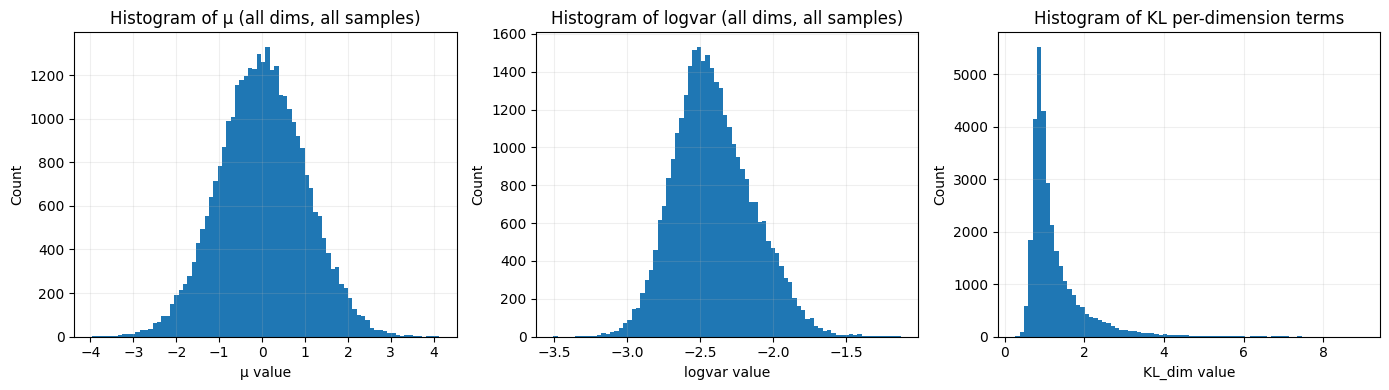

[INFO] Saved: latent_health_histograms.png


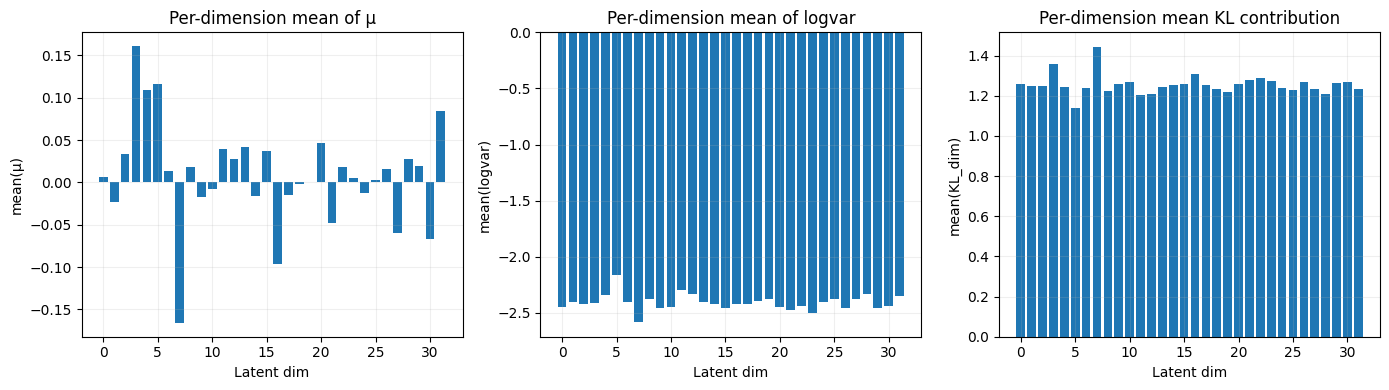

[INFO] Saved: latent_health_per_dim_bars.png


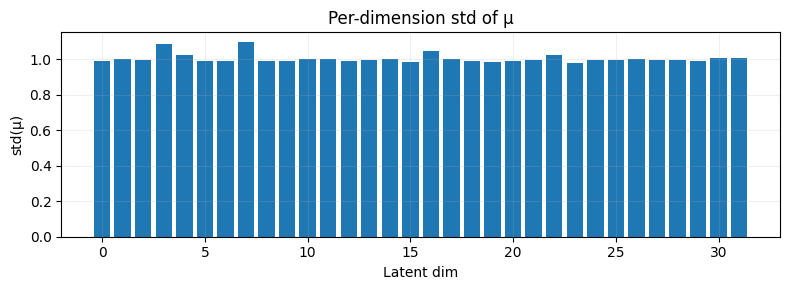

[INFO] Saved: latent_health_mu_std.png


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataloader import DiplexDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load model
# -----------------------------
latent_dim = 32
n = 3
pred_output_dim = 2**n * 10 * 2

model = VAEWithPredictor(latent_dim=latent_dim, pred_output_dim=pred_output_dim).to(device)
ckpt = torch.load("latest_vae_model_rawdeg.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# -----------------------------
# Load dataset
# -----------------------------
dataset = DiplexDataset(data_root=".", n=n, transform=None, augment_factor=1)

# If dataset is huge, subsample for speed
num_samples = min(len(dataset), 2000)  # change as needed
indices = torch.randperm(len(dataset))[:num_samples]

batch_size = 64

all_mu = []
all_logvar = []

with torch.no_grad():
    for b0 in range(0, num_samples, batch_size):
        batch_idx = indices[b0:b0+batch_size].tolist()
        xs = []
        for idx in batch_idx:
            x, _ = dataset[idx]
            xs.append(x)
        x = torch.stack(xs, dim=0).to(device)  # [B,1,80,80]

        _, _, mu, logvar, _ = model(x, noise_scale=1.0)  # mu/logvar: [B,D]
        all_mu.append(mu.cpu())
        all_logvar.append(logvar.cpu())

all_mu = torch.cat(all_mu, dim=0)         # [N,D]
all_logvar = torch.cat(all_logvar, dim=0) # [N,D]

N, D = all_mu.shape
print(f"[INFO] Collected mu/logvar for N={N}, D={D}")

# -----------------------------
# Compute per-dim stats
# -----------------------------
mu_mean = all_mu.mean(dim=0).numpy()
mu_std  = all_mu.std(dim=0).numpy()

logvar_mean = all_logvar.mean(dim=0).numpy()
logvar_std  = all_logvar.std(dim=0).numpy()

# KL per-dimension: 0.5 * (mu^2 + exp(logvar) - 1 - logvar)
kl_per_dim = 0.5 * (all_mu**2 + torch.exp(all_logvar) - 1.0 - all_logvar)  # [N,D]
kl_dim_mean = kl_per_dim.mean(dim=0).numpy()  # [D]
kl_total_mean = kl_per_dim.sum(dim=1).mean().item()

print(f"[INFO] Mean total KL per sample: {kl_total_mean:.6f}")

# Flatten for histograms
mu_flat = all_mu.numpy().reshape(-1)
logvar_flat = all_logvar.numpy().reshape(-1)
kl_flat = kl_per_dim.numpy().reshape(-1)

# -----------------------------
# Plot 1: Histograms (global)
# -----------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(mu_flat, bins=80)
plt.title("Histogram of μ (all dims, all samples)")
plt.xlabel("μ value")
plt.ylabel("Count")
plt.grid(alpha=0.2)

plt.subplot(1, 3, 2)
plt.hist(logvar_flat, bins=80)
plt.title("Histogram of logvar (all dims, all samples)")
plt.xlabel("logvar value")
plt.ylabel("Count")
plt.grid(alpha=0.2)

plt.subplot(1, 3, 3)
plt.hist(kl_flat, bins=80)
plt.title("Histogram of KL per-dimension terms")
plt.xlabel("KL_dim value")
plt.ylabel("Count")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("latent_health_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

print("[INFO] Saved: latent_health_histograms.png")

# -----------------------------
# Plot 2: Per-dimension bars (μ, logvar, KL)
# -----------------------------
dims = np.arange(D)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.bar(dims, mu_mean)
plt.title("Per-dimension mean of μ")
plt.xlabel("Latent dim")
plt.ylabel("mean(μ)")
plt.grid(alpha=0.2)

plt.subplot(1, 3, 2)
plt.bar(dims, logvar_mean)
plt.title("Per-dimension mean of logvar")
plt.xlabel("Latent dim")
plt.ylabel("mean(logvar)")
plt.grid(alpha=0.2)

plt.subplot(1, 3, 3)
plt.bar(dims, kl_dim_mean)
plt.title("Per-dimension mean KL contribution")
plt.xlabel("Latent dim")
plt.ylabel("mean(KL_dim)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("latent_health_per_dim_bars.png", dpi=300, bbox_inches="tight")
plt.show()

print("[INFO] Saved: latent_health_per_dim_bars.png")

# -----------------------------
# Plot 3: μ std per-dimension (optional but useful)
# -----------------------------
plt.figure(figsize=(8, 3))
plt.bar(dims, mu_std)
plt.title("Per-dimension std of μ")
plt.xlabel("Latent dim")
plt.ylabel("std(μ)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("latent_health_mu_std.png", dpi=300, bbox_inches="tight")
plt.show()

print("[INFO] Saved: latent_health_mu_std.png")
